# 02. ResNet-50 모델 학습
- ResNet-50 모델 정의 (Binary Classification)
- AdamW + Warmup + Cosine Annealing 스케줄러
- Early Stopping
- 평가 지표: ROC AUC (NTIRE 2026 기준)

In [1]:
# ============================================================
# 공통 모듈 import (src/ 폴더를 경로에 추가)
# ============================================================
import sys
sys.path.append("..")   # notebooks/ 에서 src/ 를 찾을 수 있도록

import torch
from src.dataset import get_dataloaders
from src.model   import build_resnet50

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"디바이스: {device}")

디바이스: cuda


In [2]:
# ============================================================
# DataLoader 준비 (한 줄로 끝!)
# ============================================================
train_loader, val_loader, test_loader, train_ds, val_ds, test_ds = get_dataloaders(
    shard_root  = "../data/train",
    shard_nums  = [0],       # shard 추가할 때 [0, 1, 2, ...] 로 늘리면 됨
    batch_size  = 32,
    num_workers = 0          # Windows 환경
)

[Dataset] shard 1개 로드 완료 — 총 50,000장
[DataLoader] Train: 40,000 | Val: 5,000 | Test: 5,000


In [3]:
# ============================================================
# 모델 정의
# ============================================================
model = build_resnet50(num_classes=2, pretrained=True).to(device)
print(f"FC 레이어: {model.fc}")

FC 레이어: Sequential(
  (0): Dropout(p=0.5, inplace=False)
  (1): Linear(in_features=2048, out_features=2, bias=True)
)


In [4]:
# ============================================================
# 하이퍼파라미터
# ============================================================
EPOCHS        = 20
WARMUP_EPOCHS = 3
LR            = 1e-4
WEIGHT_DECAY  = 1e-2
PATIENCE      = 5

In [5]:
# ============================================================
# 옵티마이저 + 스케줄러
# ============================================================
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

warmup_scheduler = LinearLR(
    optimizer, start_factor=1e-3, end_factor=1.0, total_iters=WARMUP_EPOCHS
)
cosine_scheduler = CosineAnnealingLR(
    optimizer, T_max=EPOCHS - WARMUP_EPOCHS, eta_min=1e-6
)
scheduler = SequentialLR(
    optimizer, schedulers=[warmup_scheduler, cosine_scheduler], milestones=[WARMUP_EPOCHS]
)

criterion = nn.CrossEntropyLoss()

In [6]:
# ============================================================
# 학습 루프 (Early Stopping + Best 모델 저장)
# ============================================================
from tqdm.notebook import tqdm
from sklearn.metrics import roc_auc_score
import numpy as np

best_val_auc = 0.0
patience_cnt = 0
history      = {"train_loss": [], "val_loss": [], "val_auc": []}

for epoch in range(1, EPOCHS + 1):

    # ── Train ──────────────────────────────────────────────
    model.train()
    train_loss = 0.0

    for imgs, labels in tqdm(train_loader, desc=f"[{epoch:02d}/{EPOCHS}] Train"):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * imgs.size(0)

    train_loss /= len(train_ds)
    scheduler.step()

    # ── Validation ────────────────────────────────────────
    model.eval()
    val_loss, all_probs, all_labels = 0.0, [], []

    with torch.no_grad():
        for imgs, labels in tqdm(val_loader, desc=f"[{epoch:02d}/{EPOCHS}] Val  "):
            imgs, labels = imgs.to(device), labels.to(device)
            outputs  = model(imgs)
            loss     = criterion(outputs, labels)
            val_loss += loss.item() * imgs.size(0)
            probs    = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(labels.cpu().numpy())

    val_loss /= len(val_ds)
    val_auc   = roc_auc_score(all_labels, all_probs)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_auc"].append(val_auc)

    print(f"[Epoch {epoch:02d}] Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val AUC: {val_auc:.4f} | "
          f"LR: {scheduler.get_last_lr()[0]:.2e}")

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save(model.state_dict(), "../results/best_resnet50.pth")
        print(f"  ✅ Best 모델 저장 (Val AUC: {best_val_auc:.4f})")
        patience_cnt = 0
    else:
        patience_cnt += 1
        print(f"  ⏳ Early Stopping 카운트: {patience_cnt}/{PATIENCE}")
        if patience_cnt >= PATIENCE:
            print(f"  ⛔ Early Stopping (Best Val AUC: {best_val_auc:.4f})")
            break

[01/20] Train:   0%|          | 0/1250 [00:00<?, ?it/s]

[01/20] Val  :   0%|          | 0/157 [00:00<?, ?it/s]

[Epoch 01] Train Loss: 0.7226 | Val Loss: 0.7111 | Val AUC: 0.5270 | LR: 3.34e-05
  ✅ Best 모델 저장 (Val AUC: 0.5270)


[02/20] Train:   0%|          | 0/1250 [00:00<?, ?it/s]

[02/20] Val  :   0%|          | 0/157 [00:00<?, ?it/s]

...

[19/20] Val  :   0%|          | 0/157 [00:00<?, ?it/s]

[Epoch 19] Train Loss: 0.0002 | Val Loss: 0.1640 | Val AUC: 0.9929 | LR: 1.84e-06
  ✅ Best 모델 저장 (Val AUC: 0.9929)


[20/20] Train:   0%|          | 0/1250 [00:00<?, ?it/s]

[20/20] Val  :   0%|          | 0/157 [00:00<?, ?it/s]

[Epoch 20] Train Loss: 0.0003 | Val Loss: 0.1684 | Val AUC: 0.9930 | LR: 1.00e-06
  ✅ Best 모델 저장 (Val AUC: 0.9930)


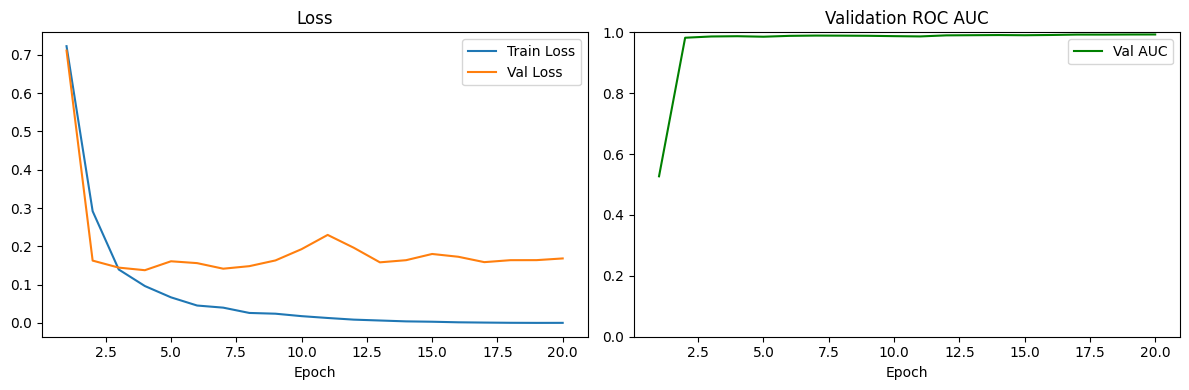

최종 Best Val AUC: 0.9930


In [7]:
# ============================================================
# 학습 곡선 시각화
# ============================================================
import matplotlib.pyplot as plt

epochs_ran = range(1, len(history["train_loss"]) + 1)
fig, axes  = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_ran, history["train_loss"], label="Train Loss")
axes[0].plot(epochs_ran, history["val_loss"],   label="Val Loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(epochs_ran, history["val_auc"], label="Val AUC", color="green")
axes[1].set_title("Validation ROC AUC")
axes[1].set_xlabel("Epoch")
axes[1].set_ylim(0, 1)
axes[1].legend()

plt.tight_layout()
plt.savefig("../results/training_curve.png", dpi=150)
plt.show()
print(f"최종 Best Val AUC: {best_val_auc:.4f}")